In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shudharshana/dichasus-csi-dataset/dichasus-cf04.tfrecords
/kaggle/input/datasets/shudharshana/dichasus-csi-dataset/spec.json
/kaggle/input/datasets/shudharshana/dichasus-csi-dataset/dichasus-cf02.tfrecords
/kaggle/input/datasets/shudharshana/dichasus-csi-dataset/dichasus-cf03.tfrecords


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-03-16 11:19:22.048089: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773659962.303324      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773659962.366718      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773659963.000624      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773659963.000696      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773659963.000699      55 computation_placer.cc:177] computation placer alr

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
dataset_path = "/kaggle/input/datasets/shudharshana/dichasus-csi-dataset/dichasus-cf02.tfrecords"

dataset = tf.data.TFRecordDataset(dataset_path)

print("Dataset loaded")

Dataset loaded


2026-03-16 11:19:50.266590: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
for raw_record in dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print(example)

features {
  feature {
    key: "time"
    value {
      float_list {
        value: 25106.9043
      }
    }
  }
  feature {
    key: "snr"
    value {
      bytes_list {
        value: "\010\001\022\004\022\002\010 "\200\001\201\331yAg \202A1TiA\377\326\221A\344r\224A\214\347tA\333NrAn\374\210A.5)AI\346+AR\222\361@&\265lAL\331\212AC\333`AJqHA;j\225A\201T\031A\317[\232A\372\350/A\216\206\203A.cN\276\255:nA\244\272\223AAK\032A\231V\277ArB\224A\005<'A\022\274\210AG\371yA\270\312\002AW7\310A2\262\027A"
      }
    }
  }
  feature {
    key: "pos-tachy"
    value {
      bytes_list {
        value: "\010\002\022\004\022\002\010\003"\030\240\202\356V&r\004\300\341sR#\204=\t\300\332\033|a2U\356?"
      }
    }
  }
  feature {
    key: "gt-interp-age-tachy"
    value {
      float_list {
        value: 0.0156224631
      }
    }
  }
  feature {
    key: "csi"
    value {
      bytes_list {
        value: "\010\001\022\r\022\002\010 \022\003\010\200\010\022\002\010\002"\200\200\020\210g*\300j

In [6]:
import tensorflow as tf
import numpy as np

dataset_path = "/kaggle/input/datasets/shudharshana/dichasus-csi-dataset/dichasus-cf02.tfrecords"

dataset = tf.data.TFRecordDataset(dataset_path)

for raw_record in dataset.take(1):

    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    features = example.features.feature

    csi_bytes = features["csi"].bytes_list.value[0]

    csi_tensor = tf.io.parse_tensor(csi_bytes, out_type=tf.float32)

    csi = csi_tensor.numpy()

    print("CSI shape:", csi.shape)

CSI shape: (32, 1024, 2)


In [7]:
csi_complex = csi[:,:,0] + 1j*csi[:,:,1]

print("Complex CSI shape:", csi_complex.shape)

Complex CSI shape: (32, 1024)


We have only collected one snapshot of CSI...For Wiener Predictor we need a time sequence of CSI values. We will do that in the next cell...

In [8]:
channels = []

for raw_record in dataset.take(300):   # take first 300 time samples
    
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    
    features = example.features.feature
    
    csi_bytes = features["csi"].bytes_list.value[0]
    csi_tensor = tf.io.parse_tensor(csi_bytes, out_type=tf.float32)
    
    csi = csi_tensor.numpy()
    
    csi_complex = csi[:,:,0] + 1j*csi[:,:,1]
    
    channels.append(csi_complex)

channels = np.array(channels)

print("Channel sequence shape:", channels.shape)
#output : (time samples, antennas, subcarriers)

Channel sequence shape: (300, 32, 1024)


In [ ]:

subcarrier_index = 0

h_sequence = channels[:, :, subcarrier_index]

print("Sequence shape:", h_sequence.shape)

Sequence shape: (300, 32)


In [10]:
K = 5   # memory length (number of past samples used)
p = 1   # prediction horizon (predict next time step)

predictions = []
truth = []

for i in range(K, len(h_sequence) - p):

    past = h_sequence[i-K:i]          # previous K channel vectors
    
    weights = np.ones(K) / K          # simple average weights
    
    pred = np.dot(weights, past)      # predicted channel
    
    predictions.append(pred)
    truth.append(h_sequence[i+p])     # true future channel

predictions = np.array(predictions)
truth = np.array(truth)

print("Prediction shape:", predictions.shape)

Prediction shape: (294, 32)


In [11]:
mse = np.mean(np.abs(predictions - truth)**2)

print("Prediction MSE:", mse)

Prediction MSE: 5.3160714890060605


Figure saved as channel_prediction_example.png


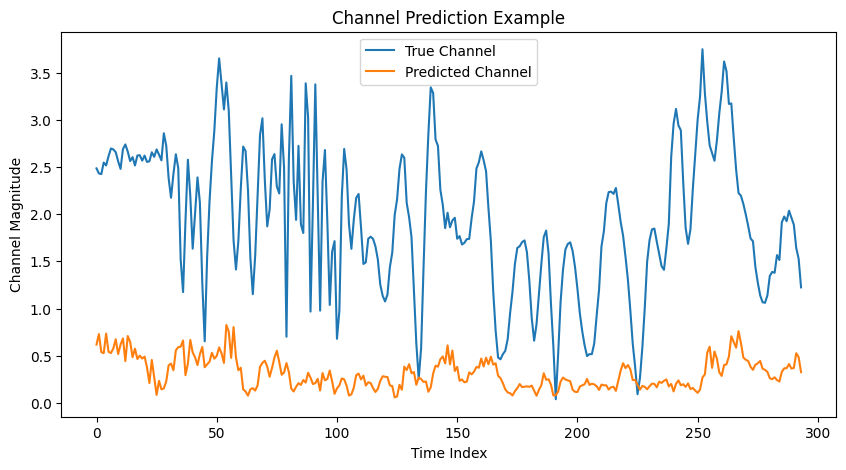

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(np.abs(truth[:,0]), label="True Channel")
plt.plot(np.abs(predictions[:,0]), label="Predicted Channel")

plt.legend()
plt.title("Channel Prediction Example")
plt.xlabel("Time Index")
plt.ylabel("Channel Magnitude")
plt.savefig("channel_prediction_example.png", dpi=300, bbox_inches="tight")
print("Figure saved as channel_prediction_example.png")
plt.show()

Test Multiple Horizons

In [13]:
max_horizon = 20
errors = []

K = 5

for p in range(1, max_horizon+1):

    predictions = []
    truth = []

    for i in range(K, len(h_sequence)-p):

        past = h_sequence[i-K:i]

        weights = np.ones(K)/K
        pred = np.dot(weights, past)

        predictions.append(pred)
        truth.append(h_sequence[i+p])

    predictions = np.array(predictions)
    truth = np.array(truth)

    mse = np.mean(np.abs(predictions-truth)**2)
    errors.append(mse)

print(errors)

[np.float64(5.3160714890060605), np.float64(5.8460497524305), np.float64(5.880934178104597), np.float64(5.787211237150034), np.float64(5.86234925035299), np.float64(5.908359532299443), np.float64(5.671924498881385), np.float64(5.932446503240204), np.float64(5.860607244838471), np.float64(5.780581061575484), np.float64(5.842732750545979), np.float64(5.833427877212742), np.float64(5.872156809637832), np.float64(5.806219979384031), np.float64(5.8484210788221045), np.float64(5.8297772938941606), np.float64(5.862558660526849), np.float64(5.826879036284143), np.float64(5.843541483372916), np.float64(5.839083840429432)]


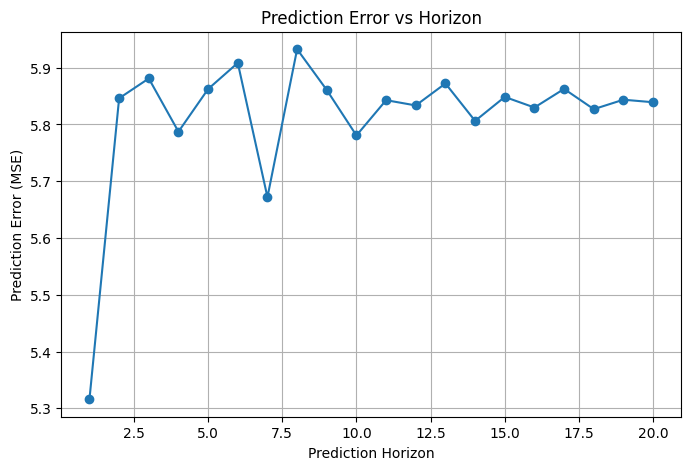

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(1,21), errors, marker="o")

plt.xlabel("Prediction Horizon")
plt.ylabel("Prediction Error (MSE)")
plt.title("Prediction Error vs Horizon")

plt.grid(True)

plt.savefig("prediction_horizon_error.png", dpi=300, bbox_inches="tight")

plt.show()